# business reference in user portrait findings, detector model training
# Portrait 1 – Cluster‑6 identity listeners (reluctant, K/J‑pop focused)
Who they are

Rare but very clear: 222 reluctant users whose listening is almost entirely cluster 6 (K/J‑pop + anime/game‑adjacent).
Median cluster‑6 share ≈ 80%, upper quartile ≈ 95%; many users have no real second cluster.
Behavior pattern: “I don’t stream often, but when I do, I come here for this scene and almost nothing else.”
Ideas for production & marketing

Treat this as a micro‑scene with strong identity: they care more about depth inside cluster 6 than breadth across the catalog.
Production: invest in high‑quality playlists, live sessions, fan‑style compilations, and artist collaborations tightly inside this scene (e.g. J‑pop/K‑pop crossovers, anime OST specials).
Marketing: low‑volume, high‑relevance campaigns—fan‑club style messaging around new releases or special events, not generic “listen more” pushes.
# Portrait 2 – Cluster‑2 ↔ Cluster‑5 bridge listeners (canon + indie/alt mix)
Who they are

795 users with top cluster 2 and second cluster 5; spread across all activity levels (≈26% reluctant, 29% below‑avg, 38% active, 7% power).
Cluster‑2 share is strong but not exclusive (median ≈ 63%), and the second cluster (5: indie/alt rock) usually has 15–30% share.
Behavior pattern: “I like the big canon / hip‑hop names, but I also explore indie/alt in a consistent way.”
Ideas for production & marketing

This group has clear potential to “level up” if discovery is good: they already cross from mainstream into discovery territory.
Production: build linked journeys—playlists and radios that start from safe canon artists, then reliably step into related indie/alt artists (cluster 5) without feeling random.
Marketing: test recommendation‑focused campaigns (“if you like X, try these underground cousins”) and track whether this segment shows above‑average gains in session length and saves.

# Technical Review – Niche User Portraits and Early‑Detection Models on Last.fm

## Table of Contents
1. Dataset and Overall Objective  
2. Building the Taste Space (NMF + KMeans)  
3. User Activity and Global Cluster–Usage Patterns  
4. Portrait 1 – Cluster‑6 Identity Users  
   4.1 Definition and EDA  
   4.2 Early‑Stage Detector Model  
5. Portrait 2 – Cluster‑2 → Cluster‑5 Bridge Users  
   5.1 Definition and EDA  
   5.2 Early‑Stage Detector Model  
6. Commercial and Technical Takeaways  

---

## 1. Dataset and Overall Objective

- **Data**: `lastfm_user_scrobbles_10k100_2021.csv` (user–artist play counts) and `artists.tsv` (artist names).  
- **Core matrix**: artists × users with integer scrobble counts.  
- **Goal**: starting from a static snapshot, use unsupervised + supervised models to  
  1. discover **niche user portraits** with clear commercial meaning, and  
  2. train **lightweight classifiers** that can detect these portraits from a small, noisy “early” patch of behavior.

---

## 2. Building the Taste Space (NMF + KMeans)

**Steps**

- Built an `artists_matrix` (rows: artists, columns: users, values: scrobbles).  
- Trained a pipeline: `MaxAbsScaler → NMF(n_components=20) → Normalizer`
  - MaxAbsScaler: rescales per‑user columns without destroying sparsity.  
  - NMF: learns 20 non‑negative latent “taste components”.  
  - Normalizer: L2‑normalizes each artist vector so dot products are cosine similarities.  
- Applied **KMeans with k = 8** on the normalized NMF features to obtain 8 artist clusters.

**Resulting clusters (simplified human labels)**

- **0** – experimental / abstract (MF DOOM, Aphex Twin, Swans …)  
- **1** – modern mainstream pop (Taylor Swift, Ariana Grande, Billie Eilish …)  
- **2** – big canon + hip‑hop crossover (Kanye, Kendrick, Beatles, Led Zeppelin …)  
- **3** – rock / metal (Metallica, Slipknot, Green Day …)  
- **4** – classical + standards (Bach, Mozart, Beethoven, Sinatra, Elvis …)  
- **5** – indie / alt rock (Radiohead, Mitski, Tame Impala …)  
- **6** – K‑/J‑pop + anime/game‑adjacent (BTS, BLACKPINK, TWICE, YOASOBI …)  
- **7** – pop divas / alt‑pop / R&B (Doja Cat, Lana Del Rey, Rihanna, Beyoncé …)

This taste space is the foundation for all user‑level analysis.

---

## 3. User Activity and Global Cluster–Usage Patterns

- Computed **total scrobbles per user**, then defined activity groups by quantiles:  
  - `reluctant` (bottom 25%), `below_avg` (25–50%), `active` (50–90%), `power` (top 10%).  
- For each user, computed **cluster_share** over the 8 clusters.  
- Built a heatmap of **average cluster_share by activity group**.

**Key observation**

- Cluster **6** (K/J‑pop) shows a *higher share for reluctant users* than for more active users.  
- Other clusters behave more like background or scale more smoothly with activity.

This suggested that cluster 6 might be an **identity scene** for some reluctant users, motivating Portrait 1.

---

## 4. Portrait 1 – Cluster‑6 Identity Users

### 4.1 Definition and EDA

- Restricted to **reluctant** users.  
- For each such user, computed total scrobbles per cluster and extracted:
  - `top_cluster`, `top_scrobbles`  
  - `second_cluster`, `second_scrobbles`  
  - `total_scrobbles_top` (sum over all clusters in the top‑artist slice).

- **Portrait 1 definition**: users with  
  - `activity_group = 'reluctant'` and  
  - `top_cluster = 6`.

- For these 222 users:

  - Median `cluster6_share` ≈ **0.79**, 75‑percentile ≈ **0.95**; many users have share = 1.0.  
  - `second_share` typically in **0.05–0.25** range; some users effectively have no strong second cluster.

**Interpretation**

- Portrait 1 users are **occasional but extremely focused** K/J‑pop listeners.  
- Commercially, this is a **micro‑scene with strong identity**: people open the platform mainly for this scene and almost nothing else.

### 4.2 Early‑Stage Detector Model

**Labeling**

- `is_niche_cluster6 = 1` for users in Portrait 1, `0` for everyone else.

**Early‑behavior features**

- Simulated an **early patch** by taking a binomial 10% sample of each (user, artist, cluster) scrobble count.  
- Recomputed `cluster_share_early` and pivoted to `X_early` (user × 8 early shares).

**Model**

- Logistic regression: `LogisticRegression(max_iter=1000, class_weight='balanced')`.

**Performance (class 1 = Portrait 1)**

- Overall accuracy ≈ **0.95**.  
- Niche class: **recall ≈ 0.95**, **precision ≈ 0.32**.

**Commercial meaning**

- A very light model can **recover almost all cluster‑6 identity users** from limited early behavior.  
- Precision is moderate but acceptable for an **insight / monitoring tool** feeding:
  - cluster‑6 specific playlisting and programming,  
  - fan‑style campaigns and notifications,  
  - dashboards that track the size and reaction of this micro‑scene over time.

---

## 5. Portrait 2 – Cluster‑2 → Cluster‑5 Bridge Users

### 5.1 Definition and EDA

- Using the same top+second cluster table for all users (`user_clusters_all`), defined:  

  - **Portrait 2**: `top_cluster = 2` and `second_cluster = 5`.

- Segment size and distribution:

  - 795 users total.  
  - ≈26% **reluctant**, 29% **below_avg**, 38% **active**, 7% **power**.

- For the reluctant subset:

  - Median `cluster2_share` ≈ **0.63** (less concentrated than Portrait 1).  
  - Median `second_share` (cluster 5) ≈ **0.20**.  
  - Second‑cluster distribution: majority choose **cluster 5**, with smaller bridges to clusters 0, 1, 3, 4, 7.

**Interpretation**

- Portrait 2 users consistently live on a **bridge between cluster 2 (canon + hip‑hop) and cluster 5 (indie/alt rock)**.  
- Unlike Portrait 1, they appear across the entire activity spectrum; high and low activity users share this taste mix.  
- Commercially, this is a **discovery‑friendly segment**: people who like both safe mainstream and exploratory indie/alt, and may respond well to richer discovery tools.

### 5.2 Early‑Stage Detector Model

**Labeling**

- `is_bridge_2_5 = 1` when `top_cluster = 2` and `second_cluster = 5`, else 0.

**Early‑behavior features**

- Reused the 10% sampling to create `cluster_share_early` and `X_early` (user × 8 early shares).

**Model**

- Logistic regression: `LogisticRegression(max_iter=1000, class_weight='balanced')`.

**Performance (class 1 = Portrait 2)**

- Overall accuracy ≈ **0.87**.  
- Bridge class: **recall ≈ 0.94**, **precision ≈ 0.38**.

**Commercial meaning**

- The model can **flag most bridge users early** with high recall.  
- The resulting candidate pool can be used to test:
  - scene‑aware recommendation flows (e.g. “from canon artist X to indie cousin Y”),  
  - personalized discovery campaigns,  
  - whether improved discovery actually increases session length, saves, and follow rates for this segment.

---

## 6. Commercial and Technical Takeaways

- **Unsupervised + simple models are enough** to reveal meaningful, business‑relevant segments:
  - NMF + KMeans yields a stable, interpretable **taste map**.  
  - Cross‑tabbing this map with activity uncovers scenes with special roles (cluster 6 as identity, 2↔5 as bridge).

- **Portrait‑level detectors**:
  - Portrait 1 and Portrait 2 detectors both achieve **~94–95% recall** from limited, noisy early data using only 8 cluster‑share features and logistic regression.  
  - These models are cheap, interpretable, and realistic to run on a daily schedule.

- **How this could be used in a real streaming product**:
  - As **segment‑finders**, not as the final recommender:
    - production teams get live insight into micro‑scenes (size, leading artists, evolution),  
    - marketing teams get high‑value target lists for fan campaigns (Portrait 1) and discovery campaigns (Portrait 2).  
  - The same framework can be extended to more portraits (other cluster combinations, language scenes, era preferences) without changing the core modeling pipeline.

Overall, the notebook demonstrates a complete path from raw scrobble counts to **ground‑truth user portraits and deployable early‑detection models**, showing how classical ML and careful EDA can already support real business decisions around niche audiences and engagement.

# Stage 1 – Reload raw data for the full map

I’ll reload the Last.fm scrobbles and artist metadata, then reconstruct the artists × users playcount matrix for the whole dataset (as in the previous notebook). This gives the same global view we used to build NMF, KMeans clusters, and finally the activity–cluster heatmap.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
scrobbles = pd.read_csv(
    "/kaggle/input/datasets/aidanbarbieux/lastfmuserartistscrobbles/lastfm_user_scrobbles_10k100_2021.csv"
)
artists = pd.read_csv(
    "/kaggle/input/datasets/aidanbarbieux/lastfmuserartistscrobbles/artists.tsv",
    sep="\t"
)

scrobbles.head(), artists.head()


(   user_id  artist_id  scrobbles
 0        0          2       1659
 1        0          1        803
 2        0          7        612
 3        0         17        380
 4        0         16        377,
    artist_id            artist_name
 0          0          Jacob Collier
 1          1        Adrianne Lenker
 2          2             Pink Floyd
 3          3  Johann Sebastian Bach
 4          4              Alfa Mist)

In [3]:
# same as before: focus on top 500 artists for a manageable matrix
artist_totals = scrobbles.groupby("artist_id")["scrobbles"].sum()
top_artist_ids = artist_totals.sort_values(ascending=False).head(500).index
scrobbles_top = scrobbles[scrobbles["artist_id"].isin(top_artist_ids)]

artists_matrix = scrobbles_top.pivot_table(
    index="artist_id", columns="user_id", values="scrobbles", fill_value=0
)
artists_matrix.shape


(500, 9958)

# Stage 2 – Learn artist taste features (NMF) and taste clusters (KMeans)

Now I recreate the same representation as in the first notebook: I fit an NMF-based pipeline on the artists × users matrix to get 20 latent “taste” features per artist, then cluster those artist vectors with KMeans (k=10). These artist clusters are the basis for building user cluster-shares and, later, the heatmap.

In [4]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import MaxAbsScaler, Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans


In [5]:
scaler = MaxAbsScaler()
nmf = NMF(n_components=20, init="random", random_state=0)
normalizer = Normalizer()
pipeline = make_pipeline(scaler, nmf, normalizer)

norm_features = pipeline.fit_transform(artists_matrix)
norm_features.shape


(500, 20)

In [6]:
# KMeans on NMF features
k = 8
kmeans = KMeans(n_clusters=k, random_state=0)
cluster_labels = kmeans.fit_predict(norm_features)

artist_names = artists.set_index("artist_id").loc[artists_matrix.index, "artist_name"]
artists_clusters = pd.DataFrame({
    "artist_id": artists_matrix.index,
    "artist": artist_names.values,
    "cluster": cluster_labels
})
artists_clusters.head()


,artist_id,artist,cluster
0,2,Pink Floyd,5
1,3,Johann Sebastian Bach,4
2,7,The Microphones,0
3,8,The Beatles,2
4,12,Thundercat,2


# Stage 3 – Rebuild user activity groups and cluster shares (k = 8)

Now I’ll: (1) compute total scrobbles per user and define activity groups by quantiles, and (2) attach the new 8-way artist clusters to each scrobble and compute, for every user, the share of their listening in each cluster. This sets up the same kind of heatmap as before, but with k = 8.


In [7]:
# Activity groups from total scrobbles
user_totals = scrobbles.groupby("user_id")["scrobbles"].sum()
quantiles = user_totals.quantile([0.25, 0.5, 0.9])

def activity_group(x):
    if x <= quantiles[0.25]:
        return "reluctant"
    elif x <= quantiles[0.5]:
        return "below_avg"
    elif x <= quantiles[0.9]:
        return "active"
    else:
        return "power"

user_activity = user_totals.to_frame("total_scrobbles")
user_activity["group"] = user_activity["total_scrobbles"].apply(activity_group)
user_activity["group"].value_counts()


group
active       3995
reluctant    2499
below_avg    2496
power         999
Name: count, dtype: int64

In [8]:
# Attach cluster labels to each (user, artist) and compute cluster shares
scrobbles_top_clustered = scrobbles_top.merge(
    artists_clusters[["artist_id", "cluster"]], on="artist_id", how="inner"
)

user_cluster = (
    scrobbles_top_clustered
    .groupby(["user_id", "cluster"])["scrobbles"].sum()
    .reset_index()
)
totals_top = user_cluster.groupby("user_id")["scrobbles"].sum().rename("user_total_top")
user_cluster = user_cluster.merge(totals_top, on="user_id")
user_cluster["cluster_share"] = user_cluster["scrobbles"] / user_cluster["user_total_top"]
user_cluster.head()


,user_id,cluster,scrobbles,user_total_top,cluster_share
0,0,0,1008,5355,0.188235
1,0,1,73,5355,0.013632
2,0,2,1795,5355,0.335201
3,0,3,84,5355,0.015686
4,0,4,354,5355,0.066106


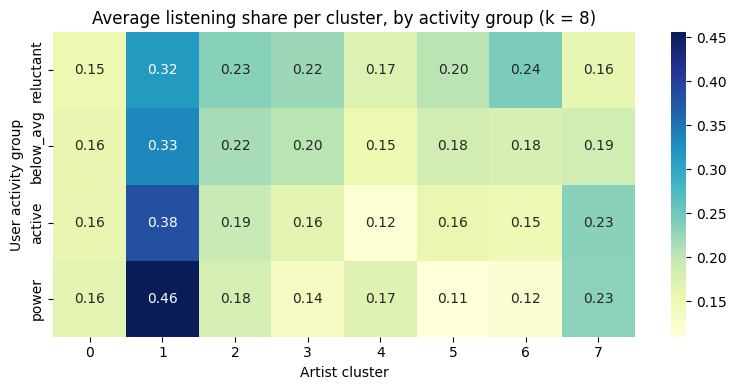

In [9]:
# Heatmap: average cluster share per activity group
user_cluster_grouped = user_cluster.merge(
    user_activity["group"], left_on="user_id", right_index=True
)
group_cluster_share = (
    user_cluster_grouped
    .groupby(["group", "cluster"])["cluster_share"]
    .mean()
    .reset_index()
)
group_cluster_pivot = group_cluster_share.pivot(index="group", columns="cluster", values="cluster_share")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.heatmap(group_cluster_pivot.loc[["reluctant","below_avg","active","power"]],
            annot=True, fmt=".2f", cmap="YlGnBu")
plt.xlabel("Artist cluster")
plt.ylabel("User activity group")
plt.title("Average listening share per cluster, by activity group (k = 8)")
plt.tight_layout()
plt.show()


# Stage 4 – Summarize each cluster with its top artists

To understand what each of the 8 clusters represents, I’ll rank artists inside each cluster by their total scrobbles and print the top few names. This will let me attach human labels (e.g. pop, metal, classical) to the clusters before I define any niche user segments.


In [10]:
# total scrobbles per artist (using the top-artist subset we clustered)
artist_totals_top = scrobbles_top.groupby("artist_id")["scrobbles"].sum()

artists_clusters = artists_clusters.copy()
artists_clusters["total_scrobbles"] = artists_clusters["artist_id"].map(artist_totals_top)
artists_clusters.head()


,artist_id,artist,cluster,total_scrobbles
0,2,Pink Floyd,5,255808
1,3,Johann Sebastian Bach,4,178576
2,7,The Microphones,0,34740
3,8,The Beatles,2,360061
4,12,Thundercat,2,126292


In [11]:
for c in range(k):  # k = 8
    print(f"\nCluster {c} (artists: { (artists_clusters['cluster'] == c).sum() })")
    top = (
        artists_clusters[artists_clusters["cluster"] == c]
        .sort_values("total_scrobbles", ascending=False)
        .head(15)
    )
    print(", ".join(top["artist"].tolist()))



Cluster 0 (artists: 41)
Death Grips, JPEGMAFIA, MF DOOM, Madvillain, Bladee, Aphex Twin, Björk, Frank Zappa, Swans, Boards of Canada, Danny Brown, Kate Bush, The Beach Boys, Duster, Flying Lotus

Cluster 1 (artists: 101)
Taylor Swift, Ariana Grande, Selena Gomez, Billie Eilish, Dua Lipa, Olivia Rodrigo, Miley Cyrus, Katy Perry, The Weeknd, Little Mix, Halsey, Pabllo Vittar, Demi Lovato, Lil Nas X, Adele

Cluster 2 (artists: 96)
Kanye West, Tyler, the Creator, The Beatles, Frank Ocean, Grateful Dead, Playboi Carti, Kendrick Lamar, Drake, Mac Miller, Travi$ Scott, Led Zeppelin, Kid Cudi, Post Malone, The Rolling Stones, Phish

Cluster 3 (artists: 46)
Metallica, Slipknot, Megadeth, Queen, Linkin Park, Iron Maiden, Alice in Chains, Black Sabbath, System of a Down, AC/DC, Tool, Judas Priest, Pearl Jam, Green Day, Foo Fighters

Cluster 4 (artists: 16)
Johann Sebastian Bach, Wolfgang Amadeus Mozart, Frédéric Chopin, Ludwig van Beethoven, Antonio Vivaldi, Georg Friedrich Händel, Frank Sinatra

# Gemini reviews (compare to K=10):
Wow, expanding the dataset and reducing the cluster count from 10 to 8 really tightened things up! This is a textbook example of a clustering algorithm finding a more mathematically stable sweet spot.

By compressing the groups, the algorithm merged the smaller, highly specific subcultures (like J-Rock/K-Pop and the various pop factions) into much larger, formidable **"cultural mega-clusters."**

Here is what happened in this new 8-cluster reality:

---

### **Cluster 0: The "Deep Web" Avant-Garde & Experimental Titan**

* **Size:** 41 artists
* **What changed:** This took the "critically acclaimed" vibe of the original Cluster 0 and cranked the intensity all the way up. The algorithm successfully grouped the absolute heaviest, most experimental internet-culture darlings. Adding **Death Grips, JPEGMAFIA, Bladee, Swans,** and **Danny Brown** alongside **Aphex Twin** and **Björk** makes this the ultimate *“I care deeply about music production and sonic chaos”* cluster.

### **Cluster 1: The Imperial A-List Western Pop Engine**

* **Size:** 101 artists (Massive!)
* **What changed:** The algorithm basically took all the pure, chart-topping, radio-dominant modern pop and threw them into one giant powerhouse. This merged parts of the old mainstream pop, Brazilian pop, and modern A-list crossover. If you hear it on a global Top 50 playlist or at a stadium tour right now (**Taylor, Ariana, Billie, Olivia, Dua**), it lives here.

### **Cluster 2: The Alpha Discography & Hypebeast Canon**

* **Size:** 96 artists
* **What changed:** This is a fascinating merger. It took the core of the old hip-hop/groove cluster and fused it with absolute cultural titans. It realizes that the same audience obsessed with **Kanye, Tyler, Kendrick, and Carti** also heavily consumes the foundational, multi-album legendary discographies of **The Beatles, Led Zeppelin, and the Grateful Dead**. It’s the "Music Enthusiast / Collector" cluster.

### **Cluster 3: The Heavy Riff & Guitar Hero Pantheon**

* **Size:** 46 artists
* **What changed:** This grew slightly and got much purer. It shed the lighter alternative rock bands and doubled down on heavy, guitar-driven music. Fusing classic metal (**Iron Maiden, Judas Priest, Black Sabbath**) with 90s/00s grunge and alt-metal (**Slipknot, System of a Down, Tool, Alice in Chains**) makes this a beautifully cohesive rock/metal powerhouse.

### **Cluster 4: Classical Focus & Nostalgic Foundations**

* **Size:** 16 artists
* **What changed:** This stayed small, tight, and highly isolated, which means the mathematical distance between classical music and everything else is incredibly wide. It’s almost identical to before—pure instrumental genius, traditional pop roots, and focus music. (Shoutout to *Sedyy Beats* for sneaking into the Bach party, likely via a classical-sample lo-fi study playlist).

### **Cluster 5: The Alternative & Indie Rock Hall of Fame**

* **Size:** 95 artists
* **What changed:** This ballooned into a massive indie-alternative mega-cluster. It seamlessly blends the sad/indie-pop corner (**Phoebe Bridgers, Mitski**) with 90s grunge (**Nirvana**), psych-rock (**Tame Impala, King Gizzard**), and 2000s festival headliners (**Radiohead, Arctic Monkeys, Coldplay**). It perfectly captures the "indie kid" trajectory over the last 30 years.

### **Cluster 6: The Global East Asian Pop & Internet Culture Merge**

* **Size:** 38 artists
* **What changed:** **The algorithm merged K-Pop and J-Pop/Gaming music into one definitive East Asian cultural cluster.** Last time, BTS/BLACKPINK were separated from YOASOBI/Camellia. Now, the algorithm recognized that the global, internet-savvy fanbases for K-Pop, J-Rock, and gaming culture overlap massively.

### **Cluster 7: The BBL, Synth-Pop, & High-Glamour Divas**

* **Size:** 67 artists
* **What changed:** This is a magnificent cluster. The algorithm separated the "clean, PG-13 stadium pop" of Cluster 1 (Taylor, Olivia) from the **high-attitude, R&B-infused, rap-crossover, and alternative-pop divas**. Putting **Doja Cat, SZA, Beyoncé, Nicki, and Rihanna** in the exact same room as **Lana Del Rey, Lorde, Charli XCX, and Lady Gaga** makes total sense culturally—this is the internet's definitive "cool-girl / club culture" soundtrack.

---



# Stage 5 – Why I focus on cluster 6 and reluctant users

In the heatmap, cluster 6 stands out because reluctant users give it a *higher* listening share than the more active groups. That suggests a specific behavior pattern: these users do not stream a lot in general, but when they do open the platform, they mainly come for this K/J‑pop scene. In other words, cluster 6 looks like an “identity cluster” for a niche audience of occasional but very focused listeners. In the next steps I’ll identify exactly which users are strongly attached to cluster 6 and study their taste profile in more detail.


In [12]:
# Per-cluster scrobbles for reluctant users (setup for Stage 5)
reluctant_ids = user_activity[user_activity["group"] == "reluctant"].index

rel_user_cluster = user_cluster[user_cluster["user_id"].isin(reluctant_ids)].copy()
totals_rel = (
    rel_user_cluster.groupby("user_id")["scrobbles"]
    .sum()
    .rename("total_scrobbles_top")
)

rel_user_cluster.head()


,user_id,cluster,scrobbles,user_total_top,cluster_share
34,8,3,131,419,0.312649
35,8,5,16,419,0.038186
36,8,6,272,419,0.649165
43,10,1,1701,3166,0.537271
44,10,2,40,3166,0.012634


In [13]:
# Per-cluster scrobbles for reluctant users
rel_cluster_totals = (
    rel_user_cluster.groupby(["user_id", "cluster"])["scrobbles"]
    .sum()
    .reset_index()
)

# Sort by scrobbles within each user to get top and second clusters
rel_sorted = rel_cluster_totals.sort_values(
    ["user_id", "scrobbles"], ascending=[True, False]
)
top = rel_sorted.drop_duplicates("user_id").rename(
    columns={"cluster": "top_cluster", "scrobbles": "top_scrobbles"}
)
second = (
    rel_sorted.groupby("user_id").nth(1).reset_index()
    .rename(columns={"cluster": "second_cluster", "scrobbles": "second_scrobbles"})
)

top = top.merge(second, on="user_id", how="left")
top = top.set_index("user_id").join(totals_rel)  # totals_rel from before
top.head()


,top_cluster,top_scrobbles,index,second_cluster,second_scrobbles,total_scrobbles_top
user_id,,,,,,
8,6,272,0.0,3.0,131.0,419
10,1,1701,7.0,7.0,878.0,3166
13,1,1033,11.0,5.0,532.0,2031
17,2,451,16.0,3.0,87.0,635
19,6,196,18.0,5.0,91.0,287


In [14]:
# Keep only reluctant users whose top cluster is 6
top6 = top[top["top_cluster"] == 6].copy()
top6["cluster6_scrobbles"] = top6["top_scrobbles"]
top6["cluster6_share"] = top6["top_scrobbles"] / top6["total_scrobbles_top"]
top6["second_share"] = top6["second_scrobbles"] / top6["total_scrobbles_top"]

rel_cluster6_view = top6[[
    "cluster6_scrobbles", "cluster6_share", "second_cluster", "second_share"
]].sort_values("cluster6_share", ascending=False)

rel_cluster6_view.head(), rel_cluster6_view.describe()


(         cluster6_scrobbles  cluster6_share  second_cluster  second_share
 user_id                                                                  
 153                     376             1.0             NaN           NaN
 498                      63             1.0             NaN           NaN
 968                      11             1.0             NaN           NaN
 689                      50             1.0             NaN           NaN
 3700                    166             1.0             NaN           NaN,
        cluster6_scrobbles  cluster6_share  second_cluster  second_share
 count          222.000000      222.000000      188.000000    188.000000
 mean           464.864865        0.755352        2.723404      0.172260
 std            450.552632        0.207260        2.031328      0.111007
 min              5.000000        0.213147        0.000000      0.001820
 25%            121.750000        0.598197        1.000000      0.072691
 50%            328.000000        0.

# finding: ground truth_niche portrait One
There are 222 reluctant users whose dominant cluster is 6, and for them cluster6_share is huge: median ≈ 0.79 and 75% ≈ 0.95, with some users listening only to cluster 6 in this top‑artist slice (share = 1.0).
Many have no meaningful second cluster at all (NaNs), and even when a second cluster exists its average share is only ≈ 0.17, rarely above 0.25–0.30.
So these users behave like almost pure cluster‑6 listeners: when they use the platform, they overwhelmingly stay inside this K/J‑pop scene and barely touch anything else.

# Stage 6 – Prototype model: Portrait one user detector

Here I turned the “reluctant, cluster‑6‑focused” listeners into a ground‑truth niche segment (222 users) and trained a small classifier to detect them early from noisy data. I labeled users as niche (1) if, in the full snapshot, they were reluctant and had cluster 6 as their dominant scene with a very high share. Then I simulated an early listening patch by randomly keeping about 10% of each user’s scrobbles and recomputed cluster‑share features over the 8 clusters. Using only these early shares, a logistic regression with class balancing reached about 95% recall on the niche class with ~32% precision. As a prototype, this shows that a lightweight model can already flag most of the cluster‑6 identity users from limited behavior, which would be enough to feed a monitoring/reporting pipeline for production and marketing teams.


In [15]:
# 1) Ground-truth label: niche cluster-6 reluctant users
niche_ids = set(rel_cluster6_view.index)  # 222 users
all_ids = user_activity.index

labels = pd.Series(
    [1 if uid in niche_ids else 0 for uid in all_ids],
    index=all_ids,
    name="is_niche_cluster6"
)
labels.value_counts()


is_niche_cluster6
0    9767
1     222
Name: count, dtype: int64

In [16]:
# 2) Simulate an "early patch" and recompute cluster shares per user
rng = np.random.default_rng(0)
early = scrobbles_top_clustered.copy()
early["early_scrobbles"] = rng.binomial(
    n=early["scrobbles"].astype(int), p=0.1
)
early = early[early["early_scrobbles"] > 0]

user_cluster_early = (
    early.groupby(["user_id", "cluster"])["early_scrobbles"].sum()
    .reset_index()
)
totals_early = user_cluster_early.groupby("user_id")["early_scrobbles"].sum()
user_cluster_early["cluster_share_early"] = (
    user_cluster_early["early_scrobbles"] /
    user_cluster_early["user_id"].map(totals_early)
)
X_early = user_cluster_early.pivot_table(
    index="user_id", columns="cluster",
    values="cluster_share_early", fill_value=0
)
X_early.head()


cluster,0,1,2,3,4,5,6,7
user_id,,,,,,,,
0,0.198853,0.024857,0.336520,0.009560,0.072658,0.357553,0.000000,0.000000
1,0.003686,0.318182,0.013514,0.000000,0.000000,0.113022,0.000000,0.551597
2,0.000000,0.078528,0.709816,0.010429,0.000000,0.124540,0.071166,0.005521
3,0.000000,0.568182,0.000000,0.000000,0.000000,0.000000,0.213636,0.218182
5,0.368421,0.000000,0.157895,0.157895,0.000000,0.315789,0.000000,0.000000


In [17]:
# 3) Train a simple classifier to detect niche users from early cluster shares
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

common_users = X_early.index.intersection(labels.index)
X = X_early.loc[common_users].values
y = labels.loc[common_users].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(X_train, y_train)
print("Accuracy:", clf.score(X_test, y_test))
print(classification_report(y_test, clf.predict(X_test)))


Accuracy: 0.9541792547834844
              precision    recall  f1-score   support

           0       1.00      0.95      0.98      1942
           1       0.32      0.95      0.48        44

    accuracy                           0.95      1986
   macro avg       0.66      0.95      0.73      1986
weighted avg       0.98      0.95      0.97      1986



# Stage 7 – Reluctant users in cluster 2: a second niche portrait

After focusing on cluster 6, I now look at reluctant users whose main scene is cluster 2 (the big canon + hip‑hop crossover cluster). I want a comparable portrait: for each reluctant user whose top cluster is 2, how dominant is this cluster in their listening, and which other cluster comes second? This lets me see whether cluster‑2 reluctant users are also highly focused, or whether they mix their listening more broadly across scenes.


In [18]:
# 0) Reluctant users' per-cluster scrobbles
reluctant_ids = user_activity[user_activity["group"] == "reluctant"].index

rel_user_cluster = user_cluster[user_cluster["user_id"].isin(reluctant_ids)].copy()
rel_user_cluster.head()


,user_id,cluster,scrobbles,user_total_top,cluster_share
34,8,3,131,419,0.312649
35,8,5,16,419,0.038186
36,8,6,272,419,0.649165
43,10,1,1701,3166,0.537271
44,10,2,40,3166,0.012634


In [19]:
# 1) Top and second clusters per reluctant user
rel_cluster_totals = (
    rel_user_cluster.groupby(["user_id", "cluster"])["scrobbles"]
    .sum()
    .reset_index()
)
rel_sorted = rel_cluster_totals.sort_values(
    ["user_id", "scrobbles"], ascending=[True, False]
)

top = rel_sorted.drop_duplicates("user_id").rename(
    columns={"cluster": "top_cluster", "scrobbles": "top_scrobbles"}
)
second = (
    rel_sorted.groupby("user_id").nth(1).reset_index()
    .rename(columns={"cluster": "second_cluster", "scrobbles": "second_scrobbles"})
)

totals_rel = (
    rel_user_cluster.groupby("user_id")["scrobbles"]
    .sum()
    .rename("total_scrobbles_top")
)
top = (
    top.set_index("user_id")
       .merge(second.set_index("user_id"), left_index=True, right_index=True, how="left")
       .join(totals_rel)
)
top.head()


,top_cluster,top_scrobbles,index,second_cluster,second_scrobbles,total_scrobbles_top
user_id,,,,,,
8,6,272,0.0,3.0,131.0,419
10,1,1701,7.0,7.0,878.0,3166
13,1,1033,11.0,5.0,532.0,2031
17,2,451,16.0,3.0,87.0,635
19,6,196,18.0,5.0,91.0,287


In [20]:
# 2) Reluctant users whose main scene is cluster 2
top2 = top[top["top_cluster"] == 2].copy()
top2["cluster2_scrobbles"] = top2["top_scrobbles"]
top2["cluster2_share"] = top2["top_scrobbles"] / top2["total_scrobbles_top"]
top2["second_share"] = top2["second_scrobbles"] / top2["total_scrobbles_top"]

rel_cluster2_view = top2[[
    "cluster2_scrobbles", "cluster2_share", "second_cluster", "second_share"
]].sort_values("cluster2_share", ascending=False)

rel_cluster2_view.head(), rel_cluster2_view.describe()


(         cluster2_scrobbles  cluster2_share  second_cluster  second_share
 user_id                                                                  
 7936                     35             1.0             NaN           NaN
 4226                    376             1.0             NaN           NaN
 5514                     18             1.0             NaN           NaN
 9469                      2             1.0             NaN           NaN
 8762                      1             1.0             NaN           NaN,
        cluster2_scrobbles  cluster2_share  second_cluster  second_share
 count          510.000000      510.000000      505.000000    505.000000
 mean           518.239216        0.636578        3.265347      0.210185
 std            467.161198        0.179088        2.146631      0.107215
 min              1.000000        0.263889        0.000000      0.002404
 25%            158.250000        0.487973        1.000000      0.124397
 50%            381.000000        0.

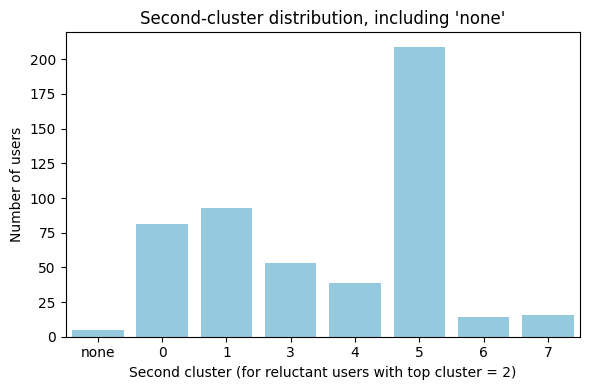

second_cluster
-1      5
 0     81
 1     93
 3     53
 4     39
 5    209
 6     14
 7     16
Name: count, dtype: int64

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -1 will mean "no second cluster" (only cluster 2)
sec = rel_cluster2_view["second_cluster"].copy()
sec_filled = sec.fillna(-1).astype(int)
sec_counts = sec_filled.value_counts().sort_index()

labels = ["none" if c == -1 else str(c) for c in sec_counts.index]

plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=sec_counts.values, color="skyblue")
plt.xlabel("Second cluster (for reluctant users with top cluster = 2)")
plt.ylabel("Number of users")
plt.title("Second-cluster distribution, including 'none'")
plt.tight_layout()
plt.show()

sec_counts


# finding: ground truth_niche portrait Two

 **“cluster‑2 listeners who strongly link to cluster‑5”** – reluctant users whose main scene is the big canon/hip‑hop cluster (2) and whose second scene is indie/alt rock (5). They’re not as “pure” as the cluster‑6 identity group, but they form a clear **bridge segment between mainstream canon + hip‑hop and indie/alt**.

In [22]:
# 1) Top and second clusters for ALL users
all_cluster_totals = (
    user_cluster.groupby(["user_id", "cluster"])["scrobbles"]
    .sum()
    .reset_index()
)
all_sorted = all_cluster_totals.sort_values(
    ["user_id", "scrobbles"], ascending=[True, False]
)

top_all = all_sorted.drop_duplicates("user_id").rename(
    columns={"cluster": "top_cluster", "scrobbles": "top_scrobbles"}
)
second_all = (
    all_sorted.groupby("user_id").nth(1).reset_index()
    .rename(columns={"cluster": "second_cluster", "scrobbles": "second_scrobbles"})
)

user_totals_top_all = (
    user_cluster.groupby("user_id")["scrobbles"]
    .sum()
    .rename("total_scrobbles_top")
)

user_clusters_all = (
    top_all.set_index("user_id")
           .merge(second_all.set_index("user_id"), left_index=True, right_index=True, how="left")
           .join(user_totals_top_all)
)
user_clusters_all.head()


,top_cluster,top_scrobbles,index,second_cluster,second_scrobbles,total_scrobbles_top
user_id,,,,,,
0,5,2041,2.0,2.0,1795.0,5355
1,7,4434,7.0,1.0,2630.0,7942
2,2,10790,14.0,5.0,1998.0,15289
3,1,12447,19.0,7.0,4619.0,21678
5,5,57,22.0,3.0,50.0,189


In [23]:
# 2) Portrait 2: top cluster = 2 and second cluster = 5
portrait2_ids = user_clusters_all[
    (user_clusters_all["top_cluster"] == 2) &
    (user_clusters_all["second_cluster"] == 5)
].index

len(portrait2_ids)


795

In [24]:
# 3) How many Portrait-2 users in each activity group?
portrait2_groups = user_activity.loc[portrait2_ids, "group"]
portrait2_groups.value_counts(), portrait2_groups.value_counts(normalize=True)


(group
 active       299
 below_avg    232
 reluctant    209
 power         55
 Name: count, dtype: int64,
 group
 active       0.376101
 below_avg    0.291824
 reluctant    0.262893
 power        0.069182
 Name: proportion, dtype: float64)

# Stage 8 – Prototype detector for Portrait 2 (cluster‑2 → cluster‑5 bridge users)

After defining Portrait 2 as users whose main scene is cluster 2 and whose second scene is cluster 5, I want to know if we can also detect this group early from limited behavior. As with Portrait 1, I simulate an early listening patch by randomly keeping about 10% of each user’s scrobbles, then recompute their early cluster shares over the 8 scenes. Using these early shares as features, I train a small logistic regression with class balancing to predict whether a user belongs to the Portrait‑2 segment. This gives a prototype model that could flag “canon + indie/alt bridge” users soon after they start listening, so product and marketing can experiment with more focused discovery experiences for them.


In [25]:
# 1) Portrait-2 labels for all users
portrait2_label = ((user_clusters_all["top_cluster"] == 2) &
                   (user_clusters_all["second_cluster"] == 5)).astype(int)
portrait2_label.value_counts()


0    9163
1     795
Name: count, dtype: int64

In [26]:
# 2) Rebuild early patch and early cluster shares
rng = np.random.default_rng(1)
early = scrobbles_top_clustered.copy()
early["early_scrobbles"] = rng.binomial(
    n=early["scrobbles"].astype(int), p=0.1
)
early = early[early["early_scrobbles"] > 0]

user_cluster_early = (
    early.groupby(["user_id", "cluster"])["early_scrobbles"].sum()
    .reset_index()
)
totals_early = user_cluster_early.groupby("user_id")["early_scrobbles"].sum()
user_cluster_early["cluster_share_early"] = (
    user_cluster_early["early_scrobbles"] /
    user_cluster_early["user_id"].map(totals_early)
)
X_early = user_cluster_early.pivot_table(
    index="user_id", columns="cluster",
    values="cluster_share_early", fill_value=0
)
X_early.shape


(9927, 8)

In [27]:
# 3) Train Portrait-2 early detector
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

common = X_early.index.intersection(portrait2_label.index)
X = X_early.loc[common].values
y = portrait2_label.loc[common].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

clf_p2 = LogisticRegression(max_iter=1000, class_weight="balanced")
clf_p2.fit(X_train, y_train)
print("Accuracy:", clf_p2.score(X_test, y_test))
print(classification_report(y_test, clf_p2.predict(X_test)))


Accuracy: 0.8716012084592145
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      1827
           1       0.38      0.94      0.54       159

    accuracy                           0.87      1986
   macro avg       0.69      0.90      0.73      1986
weighted avg       0.94      0.87      0.89      1986



The Portrait‑2 detector performs strongly as a segment finder: with only noisy early behavior it reaches about 87% overall accuracy and, more importantly, **recall ≈ 94% for Portrait‑2 users**. That means the model recovers almost all of the canon+indie/alt bridge listeners we defined from the full snapshot. Precision is around 38%, so not every flagged user truly belongs to this portrait, but for a marketing/production use case this is acceptable: the model provides a rich pool of likely bridge users that can be targeted with focused discovery experiments and then refined based on real engagement results.
